## **1. Imports & Dataset**

In [47]:
import re, os, sys
sys.path.append('..')
from typing import Literal, Optional, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import itables
itables.init_notebook_mode(all_interactive=True)    # full output display with pagination
# itables.options.maxBytes = 0  # IMPORTANT: only disable truncation for testing

from scripts.text_extractor import test_extraction_bulk, test_extraction_TC, apply_extraction, text_extraction_report

In [48]:
df = pd.read_csv('../data/interim/full.csv').drop(columns='Unnamed: 0')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18512 entries, 0 to 18511
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   property_type          18512 non-null  object 
 1   price                  17145 non-null  float64
 2   area                   18512 non-null  float64
 3   area_unit              18512 non-null  object 
 4   n_bedrooms             14294 non-null  float64
 5   n_bathrooms            13395 non-null  float64
 6   n_floors               10318 non-null  float64
 7   address                18509 non-null  object 
 8   city_province          18512 non-null  object 
 9   district               18512 non-null  object 
 10  legal_docs             16637 non-null  object 
 11  facing_direction       7815 non-null   object 
 12  front_width            10783 non-null  float64
 13  balcony_direction      4340 non-null   object 
 14  raw_price              18512 non-null  object 
 15  ra

---

## **2. Duplicates**

In [49]:
df_no_duplicates = df.drop_duplicates(subset=df.columns.difference(['scraper']))

print(f"Number of rows before removing duplicates: {len(df)}")
print(f"Number of rows after removing duplicates: {len(df_no_duplicates)}")

df = df_no_duplicates

Number of rows before removing duplicates: 18512
Number of rows after removing duplicates: 13535


---
## **3. Feature standardization**
- Non-null `area`, `front_width`, `front_road_width` values are already unified   

To-dos:
- `price` to billion VND
- `property_type` to {"Nhà mặt tiền", "Nhà hẻm", "Biệt thự", "Chung cư", "Nhà riêng", "Condotel", "Shophouse"}
- `legal_docs` to {"Sổ đỏ/hồng riêng", "Hợp đồng mua bán", "Sổ chung", "Đang chờ sổ", "Văn bản thỏa thuận", "Khác/Không rõ"}
- Unify names for `city_province`
- Unify names for `district`
- Unify directions for `facing_direction` and `balcony_direction` to lower case, separated by a space
- `interior` to {"cao cấp", "đầy đủ", "cơ bản", "chưa có"}

### &emsp; **3.1. Price**

In [50]:
df["price_unit"].unique()

array([nan, 'tỷ', 'triệu/m²', 'triệu', 'tỷ/m²'], dtype=object)

In [51]:
CONVERSION_MAP = {
    "tỷ": 1,
    "tỷ/m²": 1,
    "triệu": 1e-3,
    "triệu/m²": 1e-3,
    "nghìn/m²": 1e-6, 
    "nghìn": 1e-6   
}
def price_to_bil(row, val_col_label:str, unit_col_label:str):
    value = row[val_col_label]
    if not value:
        return None
    
    unit = row[unit_col_label]
    conversion_factor = CONVERSION_MAP.get(unit)
    if unit and conversion_factor:
        return value * conversion_factor
    else:        # from muaban_net.csv dataset
        return value

In [52]:
# convert all to billion
df["price"] = df.apply(price_to_bil, axis=1, args=("price","price_unit"))

# convert price per m2 units to full price
price_per_area = df.price_unit.isin(["tỷ/m²", "triệu/m²", "nghìn/m²"])
df.loc[price_per_area, "price"] = df.loc[price_per_area, "price"] * df.loc[price_per_area, "area"]

### &emsp; **3.2. Property type**

In [53]:
df.property_type.unique()

array(['Nhà mặt tiền', 'Nhà hẻm ngõ', 'Biệt thự', 'Biệt thự, Villa',
       'Nhà hẻm, ngõ', 'Mặt tiền', 'Căn hộ chung cư',
       'Căn hộ chung cư mini', 'Nhà riêng', 'Nhà biệt thự, liền kề',
       'Nhà mặt phố', 'Shophouse, nhà phố thương mại', 'Condotel'],
      dtype=object)

In [54]:
df.loc[df.property_type.isin(['Nhà mặt tiền', 'Mặt tiền', 'Nhà mặt phố']), 'property_type'] = 'Nhà mặt tiền'
df.loc[df.property_type.isin(['Nhà hẻm ngõ', 'Nhà hẻm, ngõ']), 'property_type'] = 'Nhà hẻm ngõ'
df.loc[df.property_type.isin(['Biệt thự', 'Biệt thự, Villa', 'Nhà biệt thự, liền kề']), 'property_type'] = 'Biệt thự'
df.loc[df.property_type.isin(['Căn hộ chung cư', 'Căn hộ chung cư mini']), 'property_type'] = 'Căn hộ chung cư'
df.loc[df.property_type.isin(['Shophouse, nhà phố thương mại']), 'property_type'] = 'Shophouse'

### &emsp; **3.3. Legal docs**

In [55]:
legals = df.legal_docs.unique()
legals

array(['Sổ hồng', 'Sổ đỏ', 'Giấy tờ hợp lệ', 'Giấy tờ khác',
       'Hợp đồng mua bán', 'Đang chờ sổ', 'Ngõ 1', 'Sổ đỏ/ Sổ hồng',
       'Sổ hồng (sử dụng chung).', 'Sổ đỏ/ Sổ hồng.', 'HĐMB', 'Sổ đỏ.',
       'Có sổ.',
       'Pháp lý chuẩn toà nhà đã có đồng sở hữu, mua bán công chứng vi bằng chuyển nhượng.',
       'Vi bằng', 'Sổ hồng riêng.', 'Sổ đỏ chính chủ, sang tên nhanh gọn',
       nan, 'Sổ sạch', 'Pháp lý: Sổ hồng riêng, thổ cư 100%.',
       'Sổ hồng đã hoàn công năm 2025', 'Đã có sổ đỏ.', 'sổ hồng 50 năm',
       'Sổ đỏ/ Sổ hồng ( sử dụng chung)', 'Có sổ',
       'Sổ đỏ đồng sở hữu - mua bán vi bằng',
       'Sổ đỏ chung của cả toà nhà, mua bán sang tên vi bằng.',
       'Sổ đỏ chung cả toà, mua bán vi bằng nhanh gọn.', 'Sổ đỏ/sổ hồng',
       'Đang chờ sổ.', 'Sổ đỏ/ Sổ hồng', 'Sổ đỏ sẵn sàng giao dịch.',
       'Sổ riêng.', 'Sổ đỏ lâu dài', 'Hợp đồng mua bán.',
       'Sổ đỏ sang tên.', 'Sổ hồng riêng hoàn công', 'Sổ hồng 50 năm',
       'Sổ hồng đồng sở hữu', 'Mua bán

In [56]:
def standardize_legal_doc_types(s: str) -> None|Literal['Sổ đỏ/hồng riêng', 'Hợp đồng mua bán', 'Sổ dùng chung', 'Văn bản thỏa thuận', 'Đang chờ sổ']:
    if not s or not isinstance(s, str) or not s.strip():
        return None
    
    s = s.lower().strip()
    s = re.sub(r'[:,.\-\/\(\)+]', '', s)

    if re.search(r'chờ sổ|chờ cấp sổ', s):
        return 'Đang chờ sổ'
    # 2 cái 'sổ' nhìn giống nhau nhưng khác (1 cái đầu có 3 kí tự là s, ô, dấu hỏi)
    if re.search(r'sổ|sổ|bìa hồng|sđ|bìa đỏ|có số|pháp\s*l[íý]:?\s*đầy đủ|đầy đủ\s*pháp\s*l[íý]|pháp\s*l[íý]\s*chuẩn|pháp\s*l[íý]\s*rõ\s*ràng|giấy tờ hợp lệ|sang tên',s):
        if re.search(r'sử dụng chung|sổ chung|đồng sở hữu|đồng sh|sdc|chung|đsh',s):
            return 'Sổ đỏ/hồng chung'
        return 'Sổ đỏ/hồng riêng'
    if re.search(r'vi bằng|vb|văn bản thoã thuận|vbtt|thỏa thuận|thoả thuận|đặt cọc|góp vốn',s):
        return 'Văn bản thỏa thuận'
    if re.search(r'hợp đồng mua bán|hđmb|hdmb|hợp đồng|hđ|hd', s):
        return 'Hợp đồng mua bán'
    else:
        return None

In [57]:
# test function
transformed = {s:standardize_legal_doc_types(s) for s in legals}
transformed

{'Sổ hồng': 'Sổ đỏ/hồng riêng',
 'Sổ đỏ': 'Sổ đỏ/hồng riêng',
 'Giấy tờ hợp lệ': 'Sổ đỏ/hồng riêng',
 'Giấy tờ khác': None,
 'Hợp đồng mua bán': 'Hợp đồng mua bán',
 'Đang chờ sổ': 'Đang chờ sổ',
 'Ngõ 1': None,
 'Sổ đỏ/ Sổ hồng': 'Sổ đỏ/hồng riêng',
 'Sổ hồng (sử dụng chung).': 'Sổ đỏ/hồng chung',
 'Sổ đỏ/ Sổ hồng.': 'Sổ đỏ/hồng riêng',
 'HĐMB': 'Hợp đồng mua bán',
 'Sổ đỏ.': 'Sổ đỏ/hồng riêng',
 'Có sổ.': 'Sổ đỏ/hồng riêng',
 'Pháp lý chuẩn toà nhà đã có đồng sở hữu, mua bán công chứng vi bằng chuyển nhượng.': 'Sổ đỏ/hồng chung',
 'Vi bằng': 'Văn bản thỏa thuận',
 'Sổ hồng riêng.': 'Sổ đỏ/hồng riêng',
 'Sổ đỏ chính chủ, sang tên nhanh gọn': 'Sổ đỏ/hồng riêng',
 nan: None,
 'Sổ sạch': 'Sổ đỏ/hồng riêng',
 'Pháp lý: Sổ hồng riêng, thổ cư 100%.': 'Sổ đỏ/hồng riêng',
 'Sổ hồng đã hoàn công năm 2025': 'Sổ đỏ/hồng riêng',
 'Đã có sổ đỏ.': 'Sổ đỏ/hồng riêng',
 'sổ hồng 50 năm': 'Sổ đỏ/hồng riêng',
 'Sổ đỏ/ Sổ hồng ( sử dụng chung)': 'Sổ đỏ/hồng chung',
 'Có sổ': 'Sổ đỏ/hồng riêng',
 'Sổ đỏ 

In [58]:
df.loc[:,'legal_docs'] = df.legal_docs.apply(standardize_legal_doc_types)

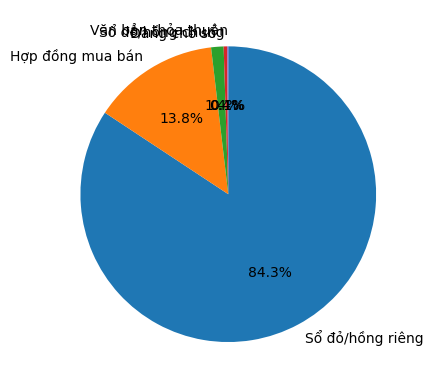

In [59]:
plt.pie(
    df.groupby('legal_docs').size().sort_values(ascending=False), 
    labels=df.groupby('legal_docs').size().sort_values(ascending=False).index, 
    startangle=90, 
    counterclock=False, 
    autopct='%1.1f%%'
)
plt.show()

### &emsp;**3.4. City/Province**

In [60]:
df.city_province.unique()

array(['TP.HCM', 'Hà Nội', 'Đà Nẵng', 'Hải Phòng', 'Cần Thơ', 'Đồng Nai',
       'Bình Dương', 'Long An', 'Lâm Đồng', 'Bà Rịa - Vũng Tàu',
       'Đắk Lắk', 'Tiền Giang', 'Bắc Ninh', 'Quảng Nam', 'Khánh Hòa',
       'Nghệ An', 'An Giang', 'Bạc Liêu', 'Bắc Giang', 'Bến Tre',
       'Bình Định', 'Bình Phước', 'Bình Thuận', 'Cà Mau', 'Đồng Tháp',
       'Gia Lai', 'Hậu Giang', 'Hưng Yên', 'Kiên Giang', 'Kon Tum',
       'Lào Cai', 'Nam Định', 'Ninh Thuận', 'Phú Thọ', 'Phú Yên',
       'Quảng Bình', 'Quảng Ngãi', 'Quảng Ninh', 'Sóc Trăng', 'Tây Ninh',
       'Thái Bình', 'Thái Nguyên', 'Thanh Hóa', 'Thừa Thiên Huế',
       'Trà Vinh', 'Vĩnh Long', 'Vĩnh Phúc', 'Yên Bái', 'Hồ Chí Minh',
       'Bà Rịa Vũng Tàu', 'Hải Dương', 'Hà Nam', 'Hòa Bình', 'Sơn La',
       'Hà Tĩnh'], dtype=object)

In [61]:
df.loc[df.city_province.isin(['Thành phố Hồ Chí Minh', 'thành phố Hồ Chí Minh', 'Hồ Chí Minh', 'TPHCM']), 'city_province'] = 'TP.HCM'
df.loc[df.city_province == 'Thành phố Hà Nội', 'city_province'] = 'Hà Nội'
df.loc[df.city_province == 'Bà Rịa - Vũng Tàu', 'city_province'] = 'Bà Rịa Vũng Tàu'

In [62]:
df.city_province.unique()

array(['TP.HCM', 'Hà Nội', 'Đà Nẵng', 'Hải Phòng', 'Cần Thơ', 'Đồng Nai',
       'Bình Dương', 'Long An', 'Lâm Đồng', 'Bà Rịa Vũng Tàu', 'Đắk Lắk',
       'Tiền Giang', 'Bắc Ninh', 'Quảng Nam', 'Khánh Hòa', 'Nghệ An',
       'An Giang', 'Bạc Liêu', 'Bắc Giang', 'Bến Tre', 'Bình Định',
       'Bình Phước', 'Bình Thuận', 'Cà Mau', 'Đồng Tháp', 'Gia Lai',
       'Hậu Giang', 'Hưng Yên', 'Kiên Giang', 'Kon Tum', 'Lào Cai',
       'Nam Định', 'Ninh Thuận', 'Phú Thọ', 'Phú Yên', 'Quảng Bình',
       'Quảng Ngãi', 'Quảng Ninh', 'Sóc Trăng', 'Tây Ninh', 'Thái Bình',
       'Thái Nguyên', 'Thanh Hóa', 'Thừa Thiên Huế', 'Trà Vinh',
       'Vĩnh Long', 'Vĩnh Phúc', 'Yên Bái', 'Hải Dương', 'Hà Nam',
       'Hòa Bình', 'Sơn La', 'Hà Tĩnh'], dtype=object)

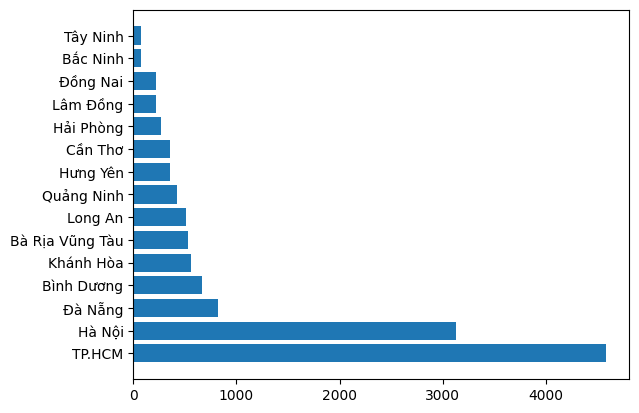

In [63]:
n=15
plt.barh(
    df.groupby('city_province').size().sort_values(ascending=False)[:n].index,
    df.groupby('city_province').size().sort_values(ascending=False)[:n]
)
plt.show()

### &emsp;**3.5. District**

In [64]:
df.loc[df.city_province == "TP.HCM", "district"].unique()

array(['Quận 5', 'Quận 7', 'Quận 6', 'Huyện Bình Chánh', 'Quận 10',
       'Quận 3', 'Quận Gò Vấp', 'Quận 1', 'Quận 12', 'Quận Tân Bình',
       'Quận Tân Phú', 'Quận Bình Thạnh', 'Quận Bình Tân', 'Quận 11',
       'Quận Phú Nhuận', 'Huyện Nhà Bè', 'Quận 8', 'TP. Thủ Đức - Quận 2',
       'Huyện Hóc Môn', 'TP. Thủ Đức - Quận Thủ Đức',
       'TP. Thủ Đức - Quận 9', 'Huyện Cần Giờ', 'Quận 4', 'Huyện Củ Chi',
       'Nhà Bè', 'Quận 2', 'Bình Thạnh', 'Gò Vấp', 'Bình Tân', 'Hóc Môn',
       'Quận 9', 'Bình Chánh', 'Tân Bình', 'Tân Phú', 'Phú Nhuận',
       'Thủ Đức', 'Cần Giờ', 'Củ Chi'], dtype=object)

In [65]:
def standardize_district(s:str)->str:
    s = s.strip().lower()
    s = re.sub(r'\s*-\s*', ' - ', s)   # For Phan Rang - Tháp Chàm

    if 'thủ đức' in s or 'quận 2' in s or 'quận 9' in s:
        return 'Thủ Đức'
    if re.search(r'quận \d+',s):
        return re.search(r'quận \d+', s).group(0).title()
    return re.sub(r'quận|^huyện|tp.|thành phố|thị xã', '', s).strip().title()

In [66]:
test_std_distr = {s: standardize_district(s) for s in df.district.unique()}
test_std_distr

{'Quận 5': 'Quận 5',
 'Quận 7': 'Quận 7',
 'Quận 6': 'Quận 6',
 'Huyện Bình Chánh': 'Bình Chánh',
 'Quận 10': 'Quận 10',
 'Quận 3': 'Quận 3',
 'Quận Gò Vấp': 'Gò Vấp',
 'Quận 1': 'Quận 1',
 'Quận 12': 'Quận 12',
 'Quận Tân Bình': 'Tân Bình',
 'Quận Tân Phú': 'Tân Phú',
 'Quận Bình Thạnh': 'Bình Thạnh',
 'Quận Bình Tân': 'Bình Tân',
 'Quận 11': 'Quận 11',
 'Quận Phú Nhuận': 'Phú Nhuận',
 'Huyện Nhà Bè': 'Nhà Bè',
 'Quận 8': 'Quận 8',
 'TP. Thủ Đức - Quận 2': 'Thủ Đức',
 'Huyện Hóc Môn': 'Hóc Môn',
 'TP. Thủ Đức - Quận Thủ Đức': 'Thủ Đức',
 'TP. Thủ Đức - Quận 9': 'Thủ Đức',
 'Huyện Cần Giờ': 'Cần Giờ',
 'Quận 4': 'Quận 4',
 'Huyện Củ Chi': 'Củ Chi',
 'Quận Ba Đình': 'Ba Đình',
 'Quận Hoàn Kiếm': 'Hoàn Kiếm',
 'Quận Hoàng Mai': 'Hoàng Mai',
 'Quận Hai Bà Trưng': 'Hai Bà Trưng',
 'Huyện Đông Anh': 'Đông Anh',
 'Quận Long Biên': 'Long Biên',
 'Quận Bắc Từ Liêm': 'Bắc Từ Liêm',
 'Quận Tây Hồ': 'Tây Hồ',
 'Quận Hà Đông': 'Hà Đông',
 'Quận Thanh Xuân': 'Thanh Xuân',
 'Quận Đống Đa': 'Đống Đa'

In [67]:
df.loc[:,'district'] = df.district.apply(standardize_district)

In [68]:
df.loc[df.city_province == "Quảng Ninh", "district"].unique()

array(['Hạ Long', 'Cẩm Phả', 'Vân Đồn', 'Uông Bí', 'Đông Triều'],
      dtype=object)

### &emsp;**3.6. Directions**

In [69]:
print(df.facing_direction.unique())
print(df.balcony_direction.unique())

[nan 'Đông Nam' 'Tây Nam' 'Tây' 'Bắc' 'Tây Bắc' 'Nam' 'Đông Bắc' 'Đông'
 'Tây - Nam' 'Đông - Nam' 'Đông - Bắc' 'Tây - Bắc']
[nan 'Đông' 'Tây Nam' 'Bắc' 'Đông Bắc' 'Nam' 'Đông Nam' 'Tây Bắc' 'Tây'
 'Đông - Nam' 'Tây - Nam' 'Đông - Bắc' 'Tây - Bắc']


In [70]:
def standardize_directions(s:str):
    if not isinstance(s, str) or not s.strip():
        return None
    return re.sub(r'\s*\-\s*', ' ', s).lower().strip()

In [71]:
df['facing_direction'] = df['facing_direction'].apply(standardize_directions)
df['balcony_direction'] = df['balcony_direction'].apply(standardize_directions)
print(df.facing_direction.unique())
print(df.balcony_direction.unique())

[None 'đông nam' 'tây nam' 'tây' 'bắc' 'tây bắc' 'nam' 'đông bắc' 'đông']
[None 'đông' 'tây nam' 'bắc' 'đông bắc' 'nam' 'đông nam' 'tây bắc' 'tây']


### &emsp;**3.7. Interior**

In [72]:
df.interior.unique()

array([nan, 'Cơ bản', 'Đầy đủ', 'Đầy đủ.', 'Không nội thất',
       'Nội thất nguyên bản.', 'Cơ bản.', 'Full nội thất cao cấp.',
       'Full nội thất như hình.', 'Đầy đủ nội thất sang xịn.',
       'Đầy đủ nội thất rất đẹp mới 100%.',
       'Đầy đủ nội thất cơ bản: Tủ bếp trên dưới, bếp từ, hút mùi, nóng lạnh, căn mẫu có: Giường, tủ quần áo,...',
       '- Tặng full nội thất giường tủ, sofa, bàn ăn, máy lạnh, tủ lạnh, tivi.',
       'Tặng full nội thất như sofa, bàn trà, kệ tivi, bàn ăn, máy lạnh, giường nệm, tủ quần áo, tab đầu giường, bàn trang điểm.. Vvv.',
       'Full nội thất.', 'Full nội thất cao cấp',
       'Nội thất đầy đủ, mới tinh.', 'Hoàn thiện mặt ngoài.',
       'Nhà được trang bị thiết bị vệ sinh cao cấp Toto và thang máy nhập khẩu hiện đại.',
       'Cao cấp', 'Nội thất đầy đủ hàng xịn nhập khẩu.',
       'Nội thất cao cấp và hệ sinh thái nhà thông minh AI',
       'Không nội thất.', 'Hoàn thiện mặt ngoài', 'Hoàn thiện cơ bản.',
       'Nội thất bàn giao nhập khẩu Ha

In [73]:
def standardize_interior(s):
    if not s or not isinstance(s, str) or not s.lower().strip():
        return None
    
    if re.search(r'cao\s*cấp|nhập\s*khẩu', s):
        return "cao cấp"
    if re.search(r'đầy\s*đủ|full|đủ|hoàn\s*thiện', s):
        return "đầy đủ"
    if re.search(r'chưa\s*có|trống|không\s*(?:có)?|thô', s):
        return "chưa có"
    # if re.search(r'cơ\s*bản|nguyên\s*bản|cb|nội\s*thất', s):
    #     return "cơ bản"
    return "cơ bản"

In [74]:
df['interior'] = df.interior.apply(standardize_interior)

In [75]:
df.interior.value_counts()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


---
## **4. Missing values**


In [76]:
main_cols = [
    'price', 'n_bedrooms', 'n_bathrooms', 'n_floors', 'front_width', 'front_road_width', 'legal_docs',
    'facing_direction', 'balcony_direction', 'interior', 'property_type', 'area', 'city_province', 'district',
]
missing = list(df[main_cols].isna().sum())
na_meaning = []
for i, col in enumerate(main_cols):
    if missing[i] == 0:
        na_meaning.append('')
        continue
    
    match col:
        case 'price':
            na_meaning.append('"Negotiation" prices')
        case 'n_floors':
            na_meaning.append('Apartments usually don\'t have `n_floors`; Not directly provided')
        case 'balcony_direction':
            na_meaning.append('Houses without balcony (1 ground floor); Not directly provided')
        case 'front_width':
            na_meaning.append('`front_width` isn\'t for Apartments/Condotels; Not directly provided')
        case 'front_road_width':
            na_meaning.append('`front_road_width` isn\'t for Apartments/Condotels; Not directly provided')
        case _:
            na_meaning.append('Not directly provided')
how_to_proceed = []
for i, col in enumerate(main_cols):
    if col == 'price':
        how_to_proceed.append('Treat as separate category for EDA; drop when modelling')
    elif col == 'legal_docs':
        how_to_proceed.append('Treat as separate category: `Khác/Không rõ`')
    else:
        if missing[i] == 0:
            how_to_proceed.append('')
        elif missing[i] < len(df) / 2:
            how_to_proceed.append('Recover -> Impute the rest')
        else:
            how_to_proceed.append('Recover -> Impute if missing ratio <50%; Drop column otherwise')

pd.DataFrame({
    'Column': main_cols,
    'Missing ratio': [f'{n_missing} / {len(df)} ({n_missing/len(df)*100:.1f} %)' for n_missing in missing],
    'Meaning of missing values': na_meaning,
    'How to proceed': how_to_proceed
})

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


### &emsp; **2.2. Understand missing patterns**

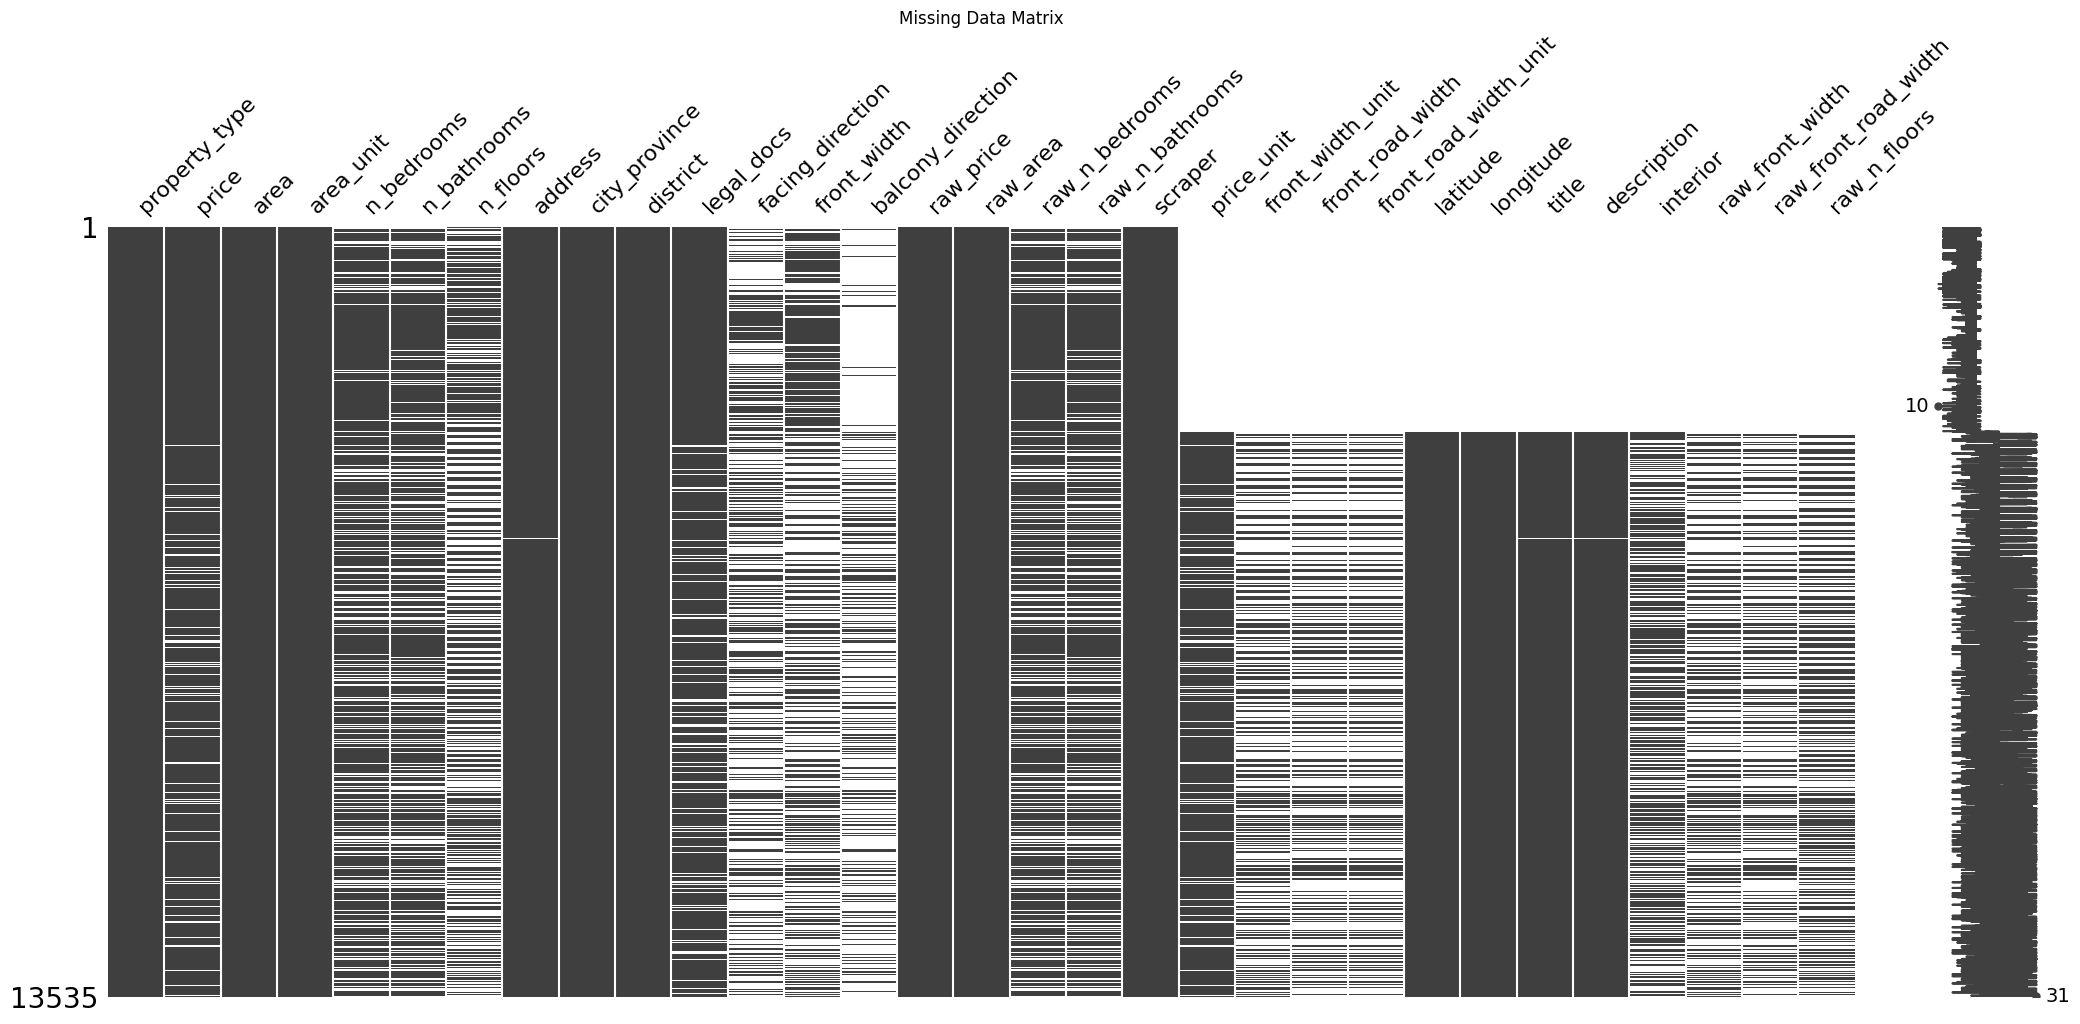

In [77]:
msno.matrix(df)
plt.title("Missing Data Matrix")
plt.show()

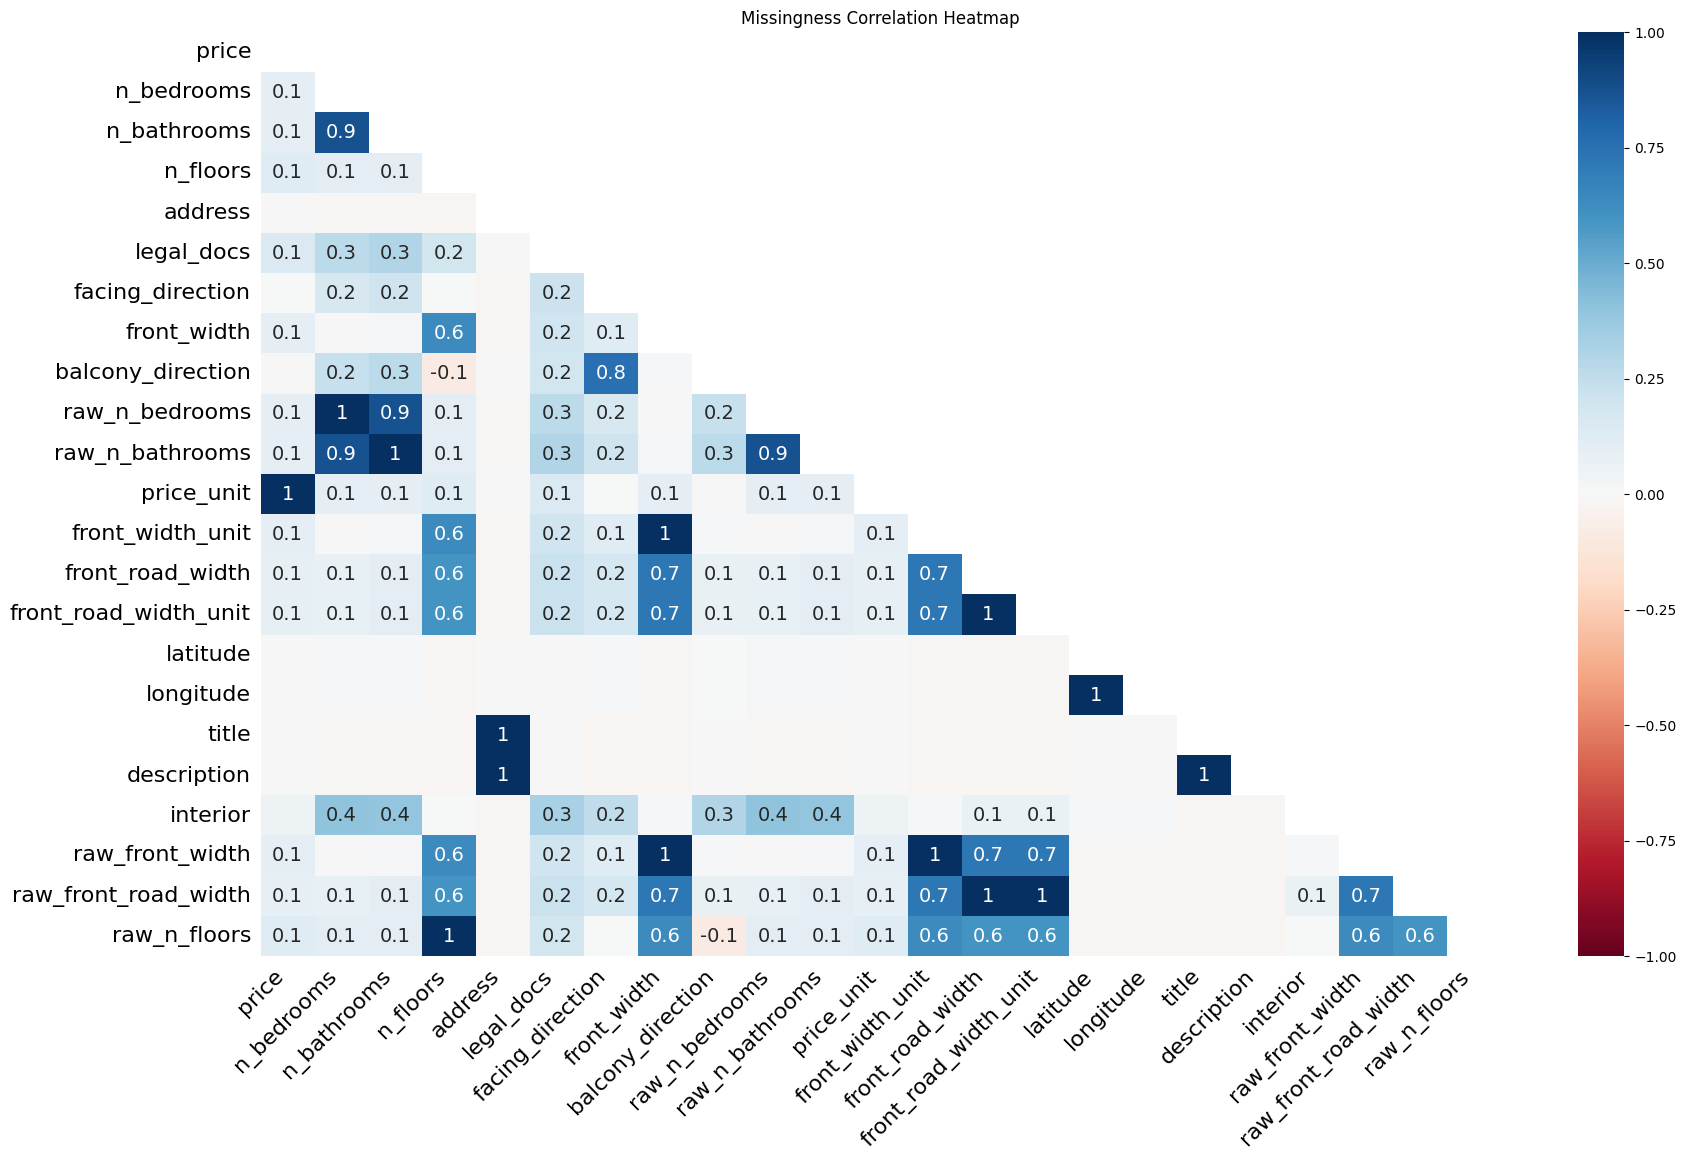

In [78]:
msno.heatmap(df.loc[df.scraper=="Quang"])
plt.title("Missingness Correlation Heatmap")
plt.show()

- All numeric columns (except `price`) all have correlation of 1 with their raw  
  $\Rightarrow$ Our conclusions that "NaN = no raw" is further justified
- Strong missing correlations: (`n_bedrooms`,`n_bathrooms`), (`balcony_direction`, `facing_direction`), (`front_width`, `front_road_width`)

In [79]:
import plotly.express as px

# # how to use radar chart
# # Data in 'Long' format
# data_long = pd.DataFrame({
#     'Entity': ['Alice', 'Alice', 'Alice', 'Alice', 'Alice',
#                'Bob', 'Bob', 'Bob', 'Bob', 'Bob'],
#     'Skill': ['Technical Skill', 'Teamwork', 'Communication', 'Problem Solving', 'Punctuality',
#               'Technical Skill', 'Teamwork', 'Communication', 'Problem Solving', 'Punctuality'],
#     'Score': [9.5, 8.0, 7.5, 9.0, 10.0,
#               7.0, 9.5, 9.0, 6.5, 8.5]
# })

na_cols = [
    'price',
    'n_bedrooms',
    'n_bathrooms',
    'n_floors',
    'front_width',
    'front_road_width',
    'legal_docs',
    'facing_direction',
    'balcony_direction',
    'interior'
]
columns = []
categories = []
completeness = []
for col in na_cols:
    df_tmp = df.groupby('property_type', as_index=False)[col].apply(lambda x: x.notna().sum()/(x.notna().sum() + x.isna().sum()))
    columns += [col] * len(df['property_type'].unique())
    categories += list(df_tmp['property_type'])
    completeness += list(df_tmp[col])

data_long = pd.DataFrame({
    'Columns': columns,
    'Categories': categories,
    'Completeness': completeness
})

fig = px.line_polar(
    data_long,
    r='Completeness',
    theta='Categories',
    color='Columns',
    line_close=True,
    title="Data coverage across property types",
    range_r=(0,1)
)
for trace in fig.data:
    if trace.name not in ['n_floors', 'front_width', 'front_road_width']:
        trace.visible = 'legendonly'  # hide but keep in legend

fig.show()

In [80]:
def missing_percent_by_cat(df:pd.DataFrame, category_col: str, target_col: str, ax:plt.Axes = None, plot: bool = True, normalize:bool=True) -> pd.DataFrame|None:
    na_by_group = df.groupby(category_col)[target_col].apply(lambda x: pd.Series({
        'Missing': x.isna().sum(),
        'Present': x.notna().sum(),
    })).unstack()
    if plot:
        if normalize:
            na_by_group.divide(na_by_group.sum(axis=1), axis=0).plot(kind='barh', stacked=True, ax=ax)
        else:
            na_by_group.plot(kind='barh', stacked=True, ax=ax)
        if ax:
            ax.set_xlabel(target_col + " missing percentage")
        else:
            plt.xlabel(target_col + " missing percentage")
    else:
        return na_by_group

def missing_percent_by_num(df:pd.DataFrame, source_col: str, numeric_col: str, plot: bool = True, ax:plt.Axes = None, log_transform:bool =True) -> pd.DataFrame|None:
    if plot:
        if log_transform:
            sns.violinplot(x=df[source_col].isna(), y=np.log1p(df[numeric_col]), ax=ax)
            plt.ylabel("Log-transformed " + numeric_col)
        else:
            sns.violinplot(x=df[source_col].isna(), y=df[numeric_col], ax=ax)
        ax.set_xticks([0,1], ['Present', 'Missing'])
    else:
        if log_transform:
            present = np.log1p(df[df[source_col].notna()][numeric_col])
            missing = np.log1p(df[df[source_col].isna()][numeric_col])
        else:
            present = df[df[source_col].notna()][numeric_col]
            missing = df[df[source_col].isna()][numeric_col]
        return pd.DataFrame({'Present': present, 'Missing': missing})


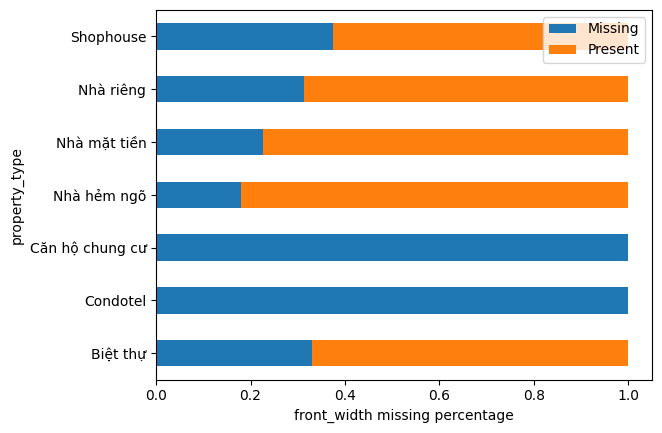

In [81]:
missing_percent_by_cat(df, 'property_type', 'front_width', plot=True)

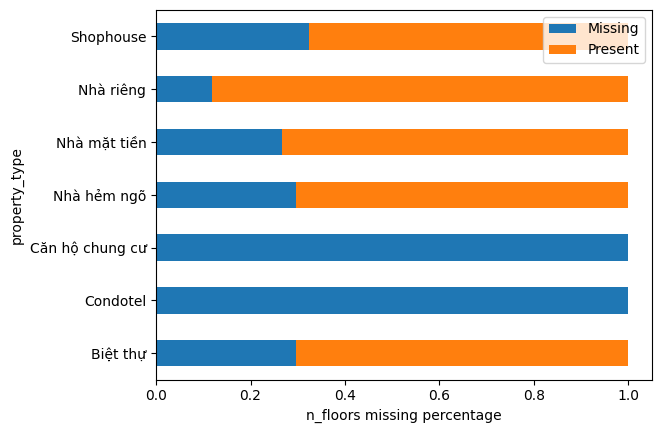

In [82]:
missing_percent_by_cat(df, 'property_type', 'n_floors', plot=True)

$\Rightarrow$ Apartments and Condotels are almost always missing the `front_width`, `n_floors`, `front_road_width` fields  
$\Rightarrow$ "Nhà hẻm ngõ" doesn't have `interior`, `front_road_width` because muaban.net doesn't have those fields

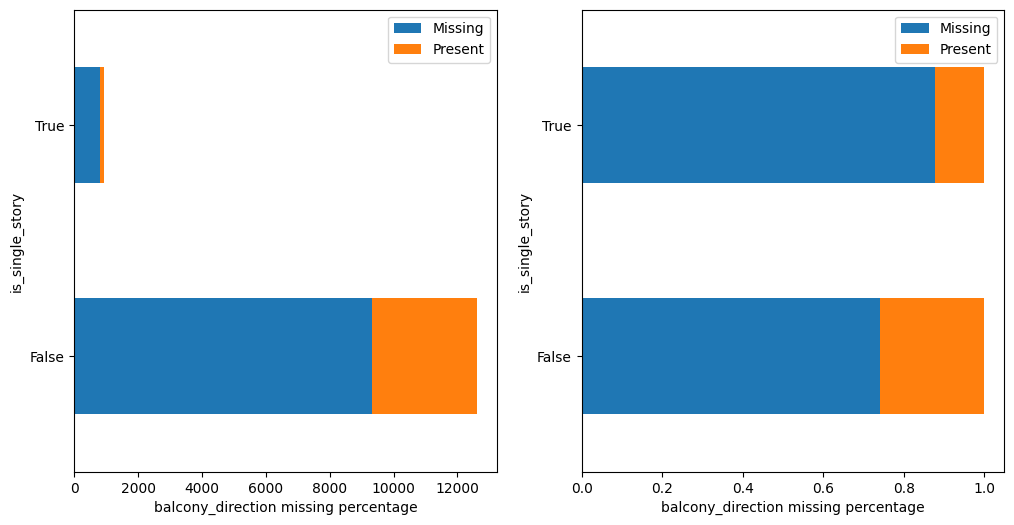

In [83]:
df["is_single_story"] = df.n_floors == 1
fig, axs = plt.subplots(1, 2, figsize=(12,6))
missing_percent_by_cat(df, 'is_single_story', 'balcony_direction', ax=axs[0], normalize=False)
missing_percent_by_cat(df, 'is_single_story', 'balcony_direction', ax=axs[1])

Observations:
- **It's weird that more than 10% of single-story houses contain values for `balcony_direction`.** Could this be because `n_floors` counts the number of floors other than the ground floor?
- Besides that, the missing percentage of `balcony_direction` for single-story house is, as suspected, higher than those with more floors

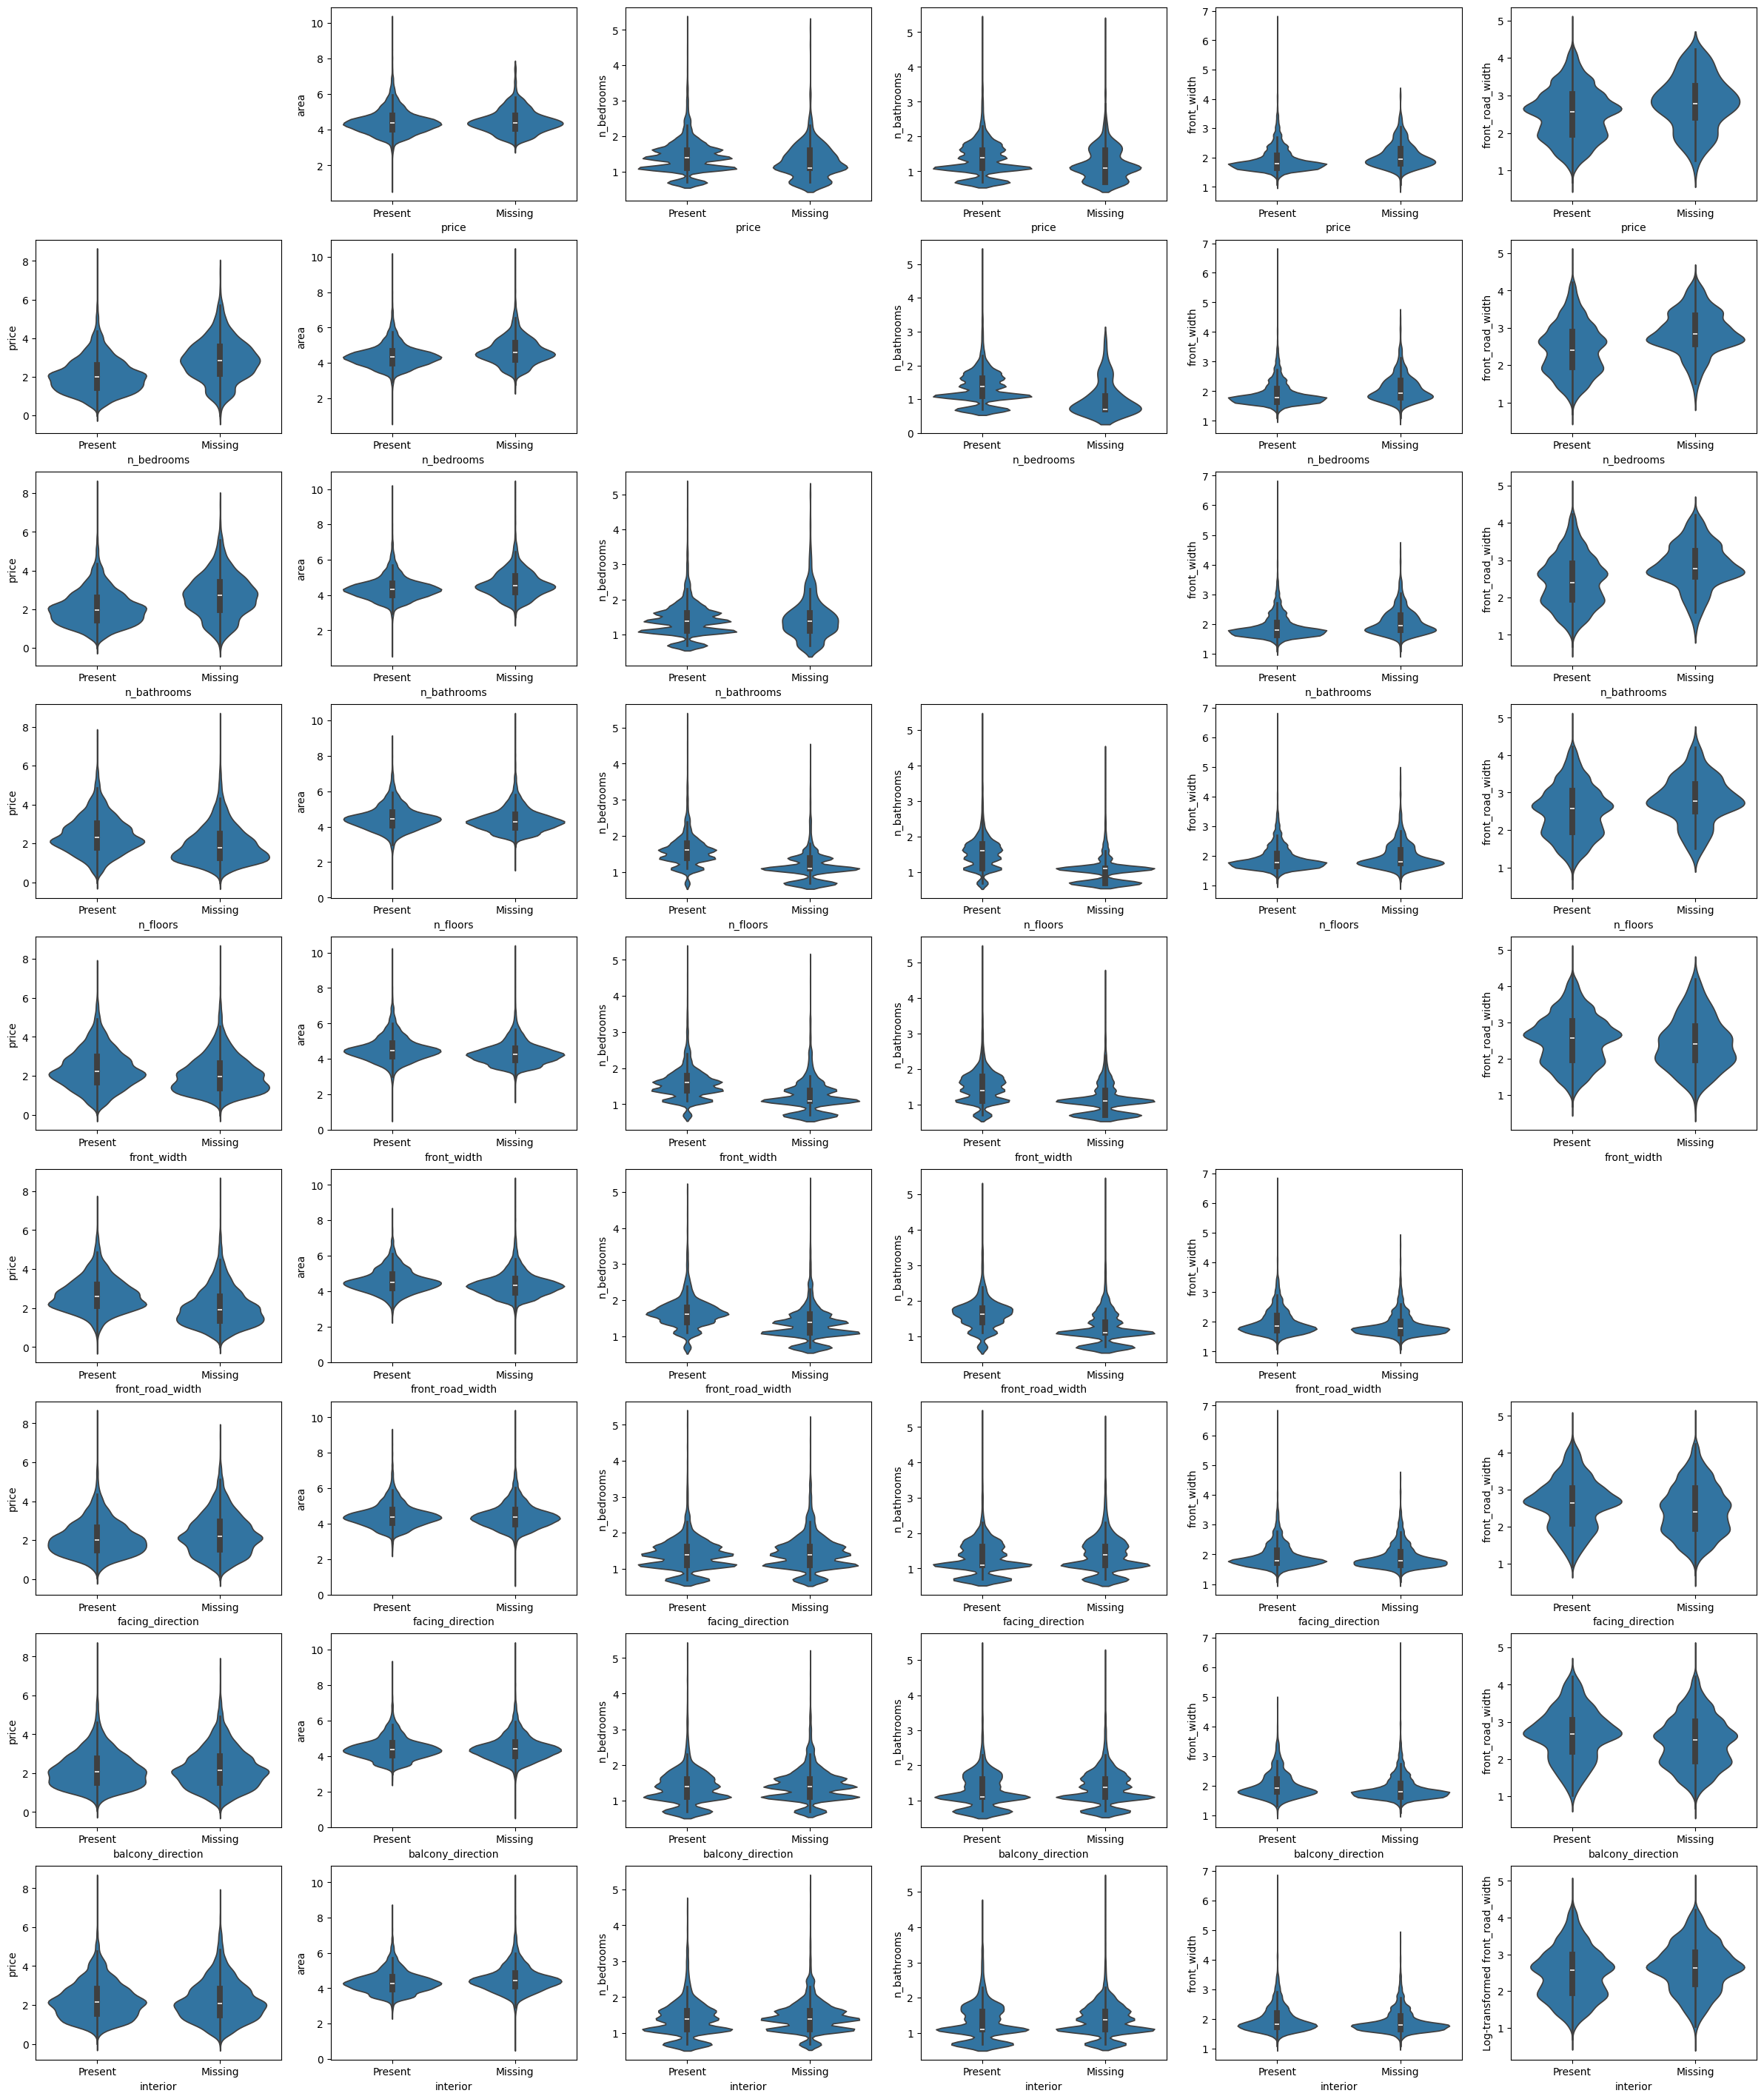

In [84]:
na_src_cols = ['price', 'n_bedrooms', 'n_bathrooms', 'n_floors', 'front_width', 'front_road_width', 'facing_direction', 'balcony_direction', 'interior']
num_target_cols = ['price', 'area', 'n_bedrooms', 'n_bathrooms', 'front_width', 'front_road_width']

fig, axs =plt.subplots(len(na_src_cols), len(num_target_cols), figsize=(5*len(num_target_cols), 4*len(na_src_cols)))
for i, na_col in enumerate(na_src_cols):
    for j, num_col in enumerate(num_target_cols):
        if na_col == num_col:
            axs[i,j].axis('off')
            continue
        missing_percent_by_num(df, na_col, num_col, plot=True, ax=axs[i,j], log_transform=True)

# missing_percent_by_num(df, 'n_floors', 'n_bedrooms', log_transform=True)

Suspicions:
- those missing `n_bedrooms` or `n_bathrooms` tends to have higher prices (median diff is about 5B VND)
- those missing `n_floors` tends to have fewer bedrooms/bathrooms (median diff is about 2 bedrooms/bathrooms)

### &emsp; **2.3. Recover missing data using text fields + regex**

#### &emsp;&emsp; **Final checks before text extraction**

In [85]:
checked = test_extraction_bulk(
    df=df.loc[(df.property_type != 'Căn hộ chung cư')],
    extract_src_col="description",
    target_cols=["n_floors", "front_width", "front_road_width", "interior", "facing_direction", "balcony_direction"],
    n_tests=300,
    context_r=25,
    only_na_target=True,
)

checked

Extracting info: 100%|██████████| 300/300 [00:00<00:00, 7114.01it/s]

>1 unique front_width matched, ignoring all
>1 unique front_width matched, ignoring all
>1 unique front_width matched, ignoring all
>1 unique front_width matched, ignoring all


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [86]:
n_floors_tc = [
    'diện tích 230m² tầng 1 và 2, hai mặt tiền vỉa hè rộng 13.5m.',
    'Diện tích: 50m x 5 tầng\r\n\r\nMặt tiền: 4m vuông vắn\r\n\r\nThiết kế: Mỗi tầng 2 phòng + vệ sinh khép kín\r\n\r\nĐang cho thuê tầng 1: 35 triệu/tháng',
    'hồ bơi 3 tầng vô cực',
    'Diện tích đất: 4,5m x 22,5m (111,5m²) Diện tích sàn: 273,5m²\r\nKết cấu: 1 trệt + 3 lầu',
    'trệt 02 lầu sân thượng',
    '48 67mv kết cấu 1 trệt 1 lầu 3pn 3wc giá 5 ty',
    'cấu 2 tầng 2 mặt tiền rộng tới | đông đô quy mô 30 tầng nổi 3 tầng hầm chiều cao 104 25m',
    'đại học dt 7x14m 1 trệt lửng 3 tấm có sân',
    'dựng thêm kết cấu 1 trệt 1 lửng 3 lầu phòng khách bếp rộng rãi 4 phòng ngủ thoải mái cho cả gia đình 5',
    'ngọc vân q12 kết cấu trệt 2 lầu btct kiên cố tường móng',
    'thống đỗ xe rất thoáng tầng 1 2 3 dãy shophouse',
    'phố nguyễn xiển 170m 5 tầng vị trí nhà ngõ 168💩trãi căn góc 170m 5 tầng 2 mặt tiền cực đẹp💩có thể xây buiding 8 tầng như hàng xóm đẹp nhất',
    '4x12 5 kết cấu 1 trệt 1 lửng 2 lầu 4pn 5wc phòng khách bếp'
]
test_extraction_TC('n_floors', n_floors_tc)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


#### &emsp;&emsp; **Applying text extraction**

In [87]:
# Applying n_floors extraction to properties NOT of type "Căn hộ chung cư" and "Condotel"
df_filled = apply_extraction(df, extract_src_col='description', targets=['front_road_width', 'interior', 'facing_direction', 'balcony_direction'])

mask_n_floors = ~df.property_type.isin(["Căn hộ chung cư", "Condotel"])
df_filled.loc[mask_n_floors] = apply_extraction(df_filled.loc[mask_n_floors], extract_src_col='description', targets=['n_floors', 'front_width'])

text_extraction_report(df, df_filled, targets=['n_floors', 'front_width', 'front_road_width', 'interior', 'facing_direction', 'balcony_direction'])

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


### &emsp; **2.4. Strategies for truly missing values** (*For regression analysis only*)
Drop unsalvageable columns: `balcony_direction`, `front_road_width`, `facing_direction`, `interior`

- MCAR (missing completely at random):  
    + Mean/Median/Mode imputation
    + Multiple imputation
- MAR (missingness can be answered by other variables):  
    + (`n_bedrooms`, `n_bathrooms`): Imputation using the other variable (Regression/KNN/Multiple imputation)
    + (`property_type`, `front_width`): Leave as missing/0 for "Căn hộ chung cư" and "Condotel", and/or use conditional imputation for the rest

## **Checkpoint 1: Analysis-ready data**

In [88]:
checkpoint_df = df_filled[['property_type', 'price', 'area', 'n_bedrooms', 'n_bathrooms', 'n_floors', 'city_province', 'district', 'legal_docs', 'facing_direction', 'front_width', 'front_road_width', 'balcony_direction', 'interior']].reset_index(drop=True)
checkpoint_df

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [89]:
checkpoint_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13535 entries, 0 to 13534
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   property_type      13535 non-null  object 
 1   price              12547 non-null  float64
 2   area               13535 non-null  float64
 3   n_bedrooms         10648 non-null  float64
 4   n_bathrooms        9957 non-null   float64
 5   n_floors           7921 non-null   float64
 6   city_province      13535 non-null  object 
 7   district           13535 non-null  object 
 8   legal_docs         12197 non-null  object 
 9   facing_direction   5778 non-null   object 
 10  front_width        8018 non-null   float64
 11  front_road_width   3987 non-null   float64
 12  balcony_direction  3408 non-null   object 
 13  interior           6560 non-null   object 
dtypes: float64(7), object(7)
memory usage: 1.4+ MB


In [90]:
df.describe(include="all")

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [91]:
checkpoint_df.to_csv('../data/processed/analysis_ready.csv', index=False)